# 04 — Evaluación del Modelo

**Objetivo:** Evaluar en detalle el mejor modelo seleccionado en `03_modeling.ipynb` (Random Forest, ROC-AUC = 0.9494) y generar los artefactos finales de evaluación.

**Contenido:**
1. Cargar modelo y datos
2. Matriz de confusión detallada
3. Curva ROC y AUC
4. Curva Precision-Recall
5. Análisis de umbral de decisión
6. Importancia de features
7. Análisis de errores
8. Resumen de métricas finales
9. Interpretabilidad con SHAP
10. Conclusiones y recomendaciones

## 1. Cargar modelo y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "../data/processed"
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

model = joblib.load("../models/best_model.joblib")

UMBRAL = 0.35
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= UMBRAL).astype(int)

print(f"Modelo cargado: {type(model).__name__}")
print(f"X_test: {X_test.shape[0]:,} filas x {X_test.shape[1]} features")
print(f"Umbral de decisi\u00f3n: {UMBRAL}")
print(f"Distribuci\u00f3n test: {y_test.value_counts().to_dict()}")

Modelo cargado: RandomForestClassifier
X_test: 1,685 filas x 48 features
Umbral de decisión: 0.35
Distribución test: {1: 1157, 0: 528}


## 2. Matriz de confusi\u00f3n detallada

La matriz de confusi\u00f3n muestra c\u00f3mo se distribuyen las predicciones **con umbral = 0.35** (ajustado para priorizar la captura de Hot Leads):
- **Verdaderos Negativos (TN):** Cold predicho como Cold \u2714
- **Falsos Positivos (FP):** Cold predicho como Hot \u2718 (el modelo dice que convierte, pero no)
- **Falsos Negativos (FN):** Hot predicho como Cold \u2718 (el modelo pierde un lead caliente)
- **Verdaderos Positivos (TP):** Hot predicho como Hot \u2714

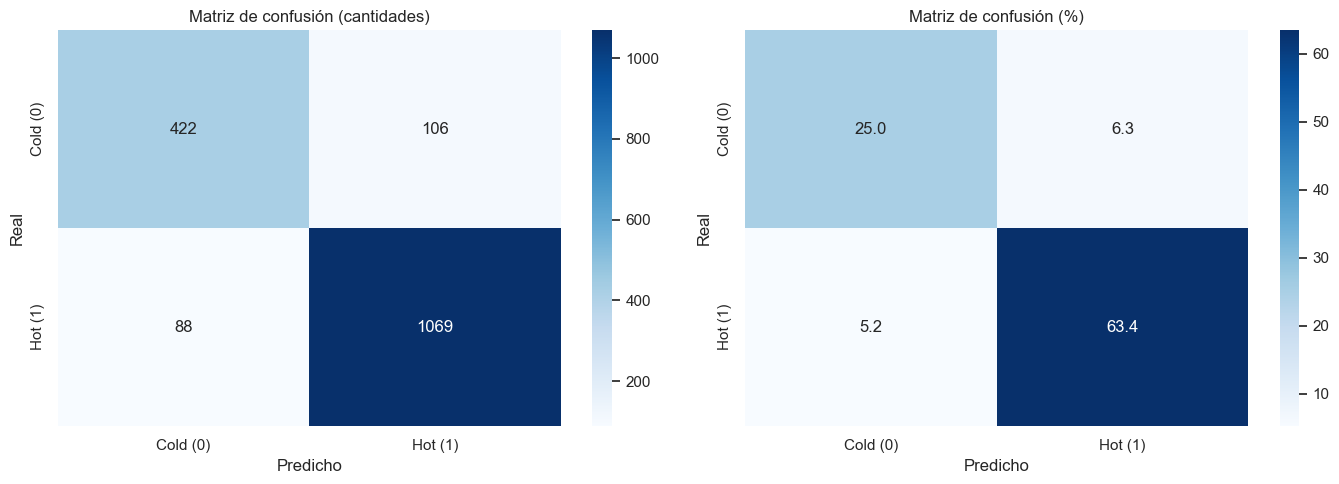


Desglose:
  Verdaderos Negativos (Cold → Cold): 422 (25.0%)
  Falsos Positivos    (Cold → Hot):  106 (6.3%)
  Falsos Negativos    (Hot → Cold):  88 (5.2%)
  Verdaderos Positivos(Hot → Hot):   1069 (63.4%)


In [2]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Cold (0)", "Hot (1)"], yticklabels=["Cold (0)", "Hot (1)"])
axes[0].set_title("Matriz de confusión (cantidades)")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

cm_pct = cm.astype(float) / cm.sum() * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[1],
            xticklabels=["Cold (0)", "Hot (1)"], yticklabels=["Cold (0)", "Hot (1)"])
axes[1].set_title("Matriz de confusión (%)")
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

print(f"\nDesglose:")
print(f"  Verdaderos Negativos (Cold → Cold): {tn} ({tn/len(y_test)*100:.1f}%)")
print(f"  Falsos Positivos    (Cold → Hot):  {fp} ({fp/len(y_test)*100:.1f}%)")
print(f"  Falsos Negativos    (Hot → Cold):  {fn} ({fn/len(y_test)*100:.1f}%)")
print(f"  Verdaderos Positivos(Hot → Hot):   {tp} ({tp/len(y_test)*100:.1f}%)")

**Conclusi\u00f3n de la matriz de confusi\u00f3n (umbral = 0.35):** El modelo acierta en el **88.5% de los casos** (422 + 1069 = 1491 de 1685). Se eligi\u00f3 un umbral m\u00e1s bajo que el default (0.5) para **priorizar no perder Hot Leads**:
- **106 Cold Leads** (6.3%) se env\u00edan err\u00f3neamente al concesionario como Hot \u2192 es un costo aceptable: el vendedor descarta estos leads r\u00e1pidamente.
- Solo **88 Hot Leads** (5.2%) se pierden \u2192 se rescataron 18 oportunidades de venta respecto al umbral 0.5 (que perd\u00eda 106).

**Trade-off:** Se acept\u00f3 enviar 44 Cold Leads adicionales al concesionario a cambio de rescatar 18 Hot Leads que antes se perd\u00edan.

## 3. Curva ROC y AUC

La curva ROC muestra la relación entre la tasa de verdaderos positivos (Recall) y la tasa de falsos positivos a distintos umbrales. Un AUC cercano a 1.0 indica excelente capacidad de discriminación.

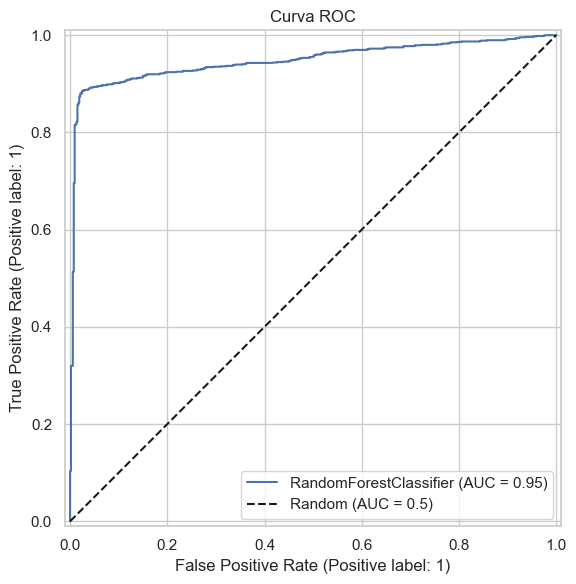

ROC-AUC: 0.9476


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, name=type(model).__name__, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

**Conclusión ROC:** Con un AUC de **0.9476**, el modelo tiene una capacidad de discriminación excelente — está muy lejos del azar (0.5) y cerca del ideal (1.0). Esto significa que si tomamos un Hot Lead y un Cold Lead al azar, el modelo le asignará una probabilidad mayor al Hot Lead el **95% de las veces**. La curva sube rápidamente hacia la esquina superior izquierda, lo que confirma que el modelo es confiable para separar ambas clases.

## 4. Curva Precision-Recall

Especialmente relevante cuando las clases están desbalanceadas. Muestra cómo cambia la precisión al variar el recall.
- **Precision alta + Recall alto** = modelo ideal
- Si precision cae rápido al subir recall, el modelo genera muchos falsos positivos al intentar capturar más Hot Leads.

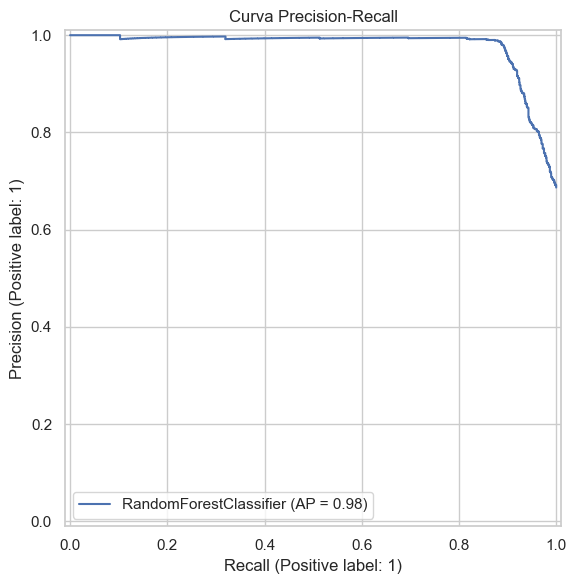

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=type(model).__name__, ax=ax)
ax.set_title("Curva Precision-Recall")
plt.tight_layout()
plt.show()

**Conclusión Precision-Recall:** La curva se mantiene alta y estable hasta un recall de ~0.85, lo que significa que el modelo puede capturar el 85% de los Hot Leads sin sacrificar precision. A partir de ahí, la precision empieza a caer más rápido: para capturar el último 15% de Hot Leads, el modelo tiene que aceptar más falsos positivos. Esto es normal y define el trade-off del negocio: ¿vale la pena enviar algunos leads fríos al concesionario para no perder ningún Hot Lead?

## 5. An\u00e1lisis de umbral de decisi\u00f3n

Se seleccion\u00f3 un umbral de **0.35** para priorizar la captura de Hot Leads (mayor Recall). El an\u00e1lisis siguiente compara distintos umbrales:
- **Umbral bajo (ej: 0.3):** Captura m\u00e1s Hot Leads (mayor Recall) pero genera m\u00e1s falsos positivos.
- **Umbral alto (ej: 0.7):** Menos falsos positivos (mayor Precision) pero pierde algunos Hot Leads.

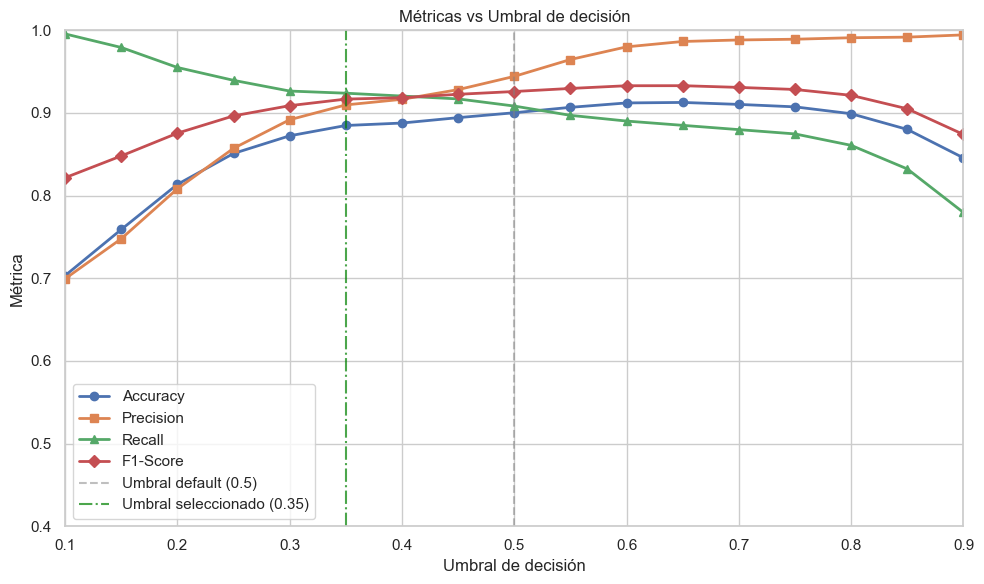

Mejor umbral por F1-Score: 0.65
  Accuracy:  0.9128
  Precision: 0.9865
  Recall:    0.8850
  F1-Score:  0.9330

Umbral seleccionado (0.35):
  Accuracy:  0.8849
  Precision: 0.9098
  Recall:    0.9239
  F1-Score:  0.9168


In [5]:
thresholds = np.arange(0.1, 0.95, 0.05)

metrics_by_threshold = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    metrics_by_threshold.append({
        "umbral": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(metrics_by_threshold)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_thresh["umbral"], df_thresh["accuracy"], "o-", label="Accuracy", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["precision"], "s-", label="Precision", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["recall"], "^-", label="Recall", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["f1"], "D-", label="F1-Score", linewidth=2)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral default (0.5)")
ax.axvline(x=UMBRAL, color="green", linestyle="-.", alpha=0.7, label=f"Umbral seleccionado ({UMBRAL})")
ax.set_xlabel("Umbral de decisi\u00f3n")
ax.set_ylabel("M\u00e9trica")
ax.set_title("M\u00e9tricas vs Umbral de decisi\u00f3n")
ax.legend()
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

best_f1_row = df_thresh.loc[df_thresh["f1"].idxmax()]
print(f"Mejor umbral por F1-Score: {best_f1_row['umbral']:.2f}")
print(f"  Accuracy:  {best_f1_row['accuracy']:.4f}")
print(f"  Precision: {best_f1_row['precision']:.4f}")
print(f"  Recall:    {best_f1_row['recall']:.4f}")
print(f"  F1-Score:  {best_f1_row['f1']:.4f}")

print(f"\nUmbral seleccionado ({UMBRAL}):")
y_sel = (y_proba >= UMBRAL).astype(int)
print(f"  Accuracy:  {accuracy_score(y_test, y_sel):.4f}")
print(f"  Precision: {precision_score(y_test, y_sel):.4f}")
print(f"  Recall:    {recall_score(y_test, y_sel):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_sel):.4f}")

**Conclusi\u00f3n del an\u00e1lisis de umbral:** El mejor F1-Score se alcanza en **0.65**, pero se seleccion\u00f3 **0.35** priorizando el Recall (capturar la mayor cantidad de Hot Leads):

| Umbral | Accuracy | Precision | Recall | F1 | Estrategia |
|--------|----------|-----------|--------|-----|------------|
| 0.50 (default) | 90.0% | 94.4% | 90.8% | 92.6% | Equilibrado |
| **0.35 (seleccionado)** | **88.5%** | **91.0%** | **92.4%** | **91.7%** | **Priorizar Hot Leads** |
| 0.65 (mejor F1) | 91.3% | 98.7% | 88.5% | 93.3% | Priorizar precisi\u00f3n |

**Justificaci\u00f3n:** Perder un Hot Lead (venta de un auto no realizada) es m\u00e1s costoso que enviar un Cold Lead al concesionario (unos minutos del vendedor). Por eso se baj\u00f3 el umbral para rescatar 18 Hot Leads adicionales, aceptando 44 Cold Leads extras.

## 6. Importancia de features

Qué variables tienen más peso en la predicción del modelo. Esto ayuda a entender **por qué** el modelo toma sus decisiones y si tiene sentido desde el punto de vista de negocio.

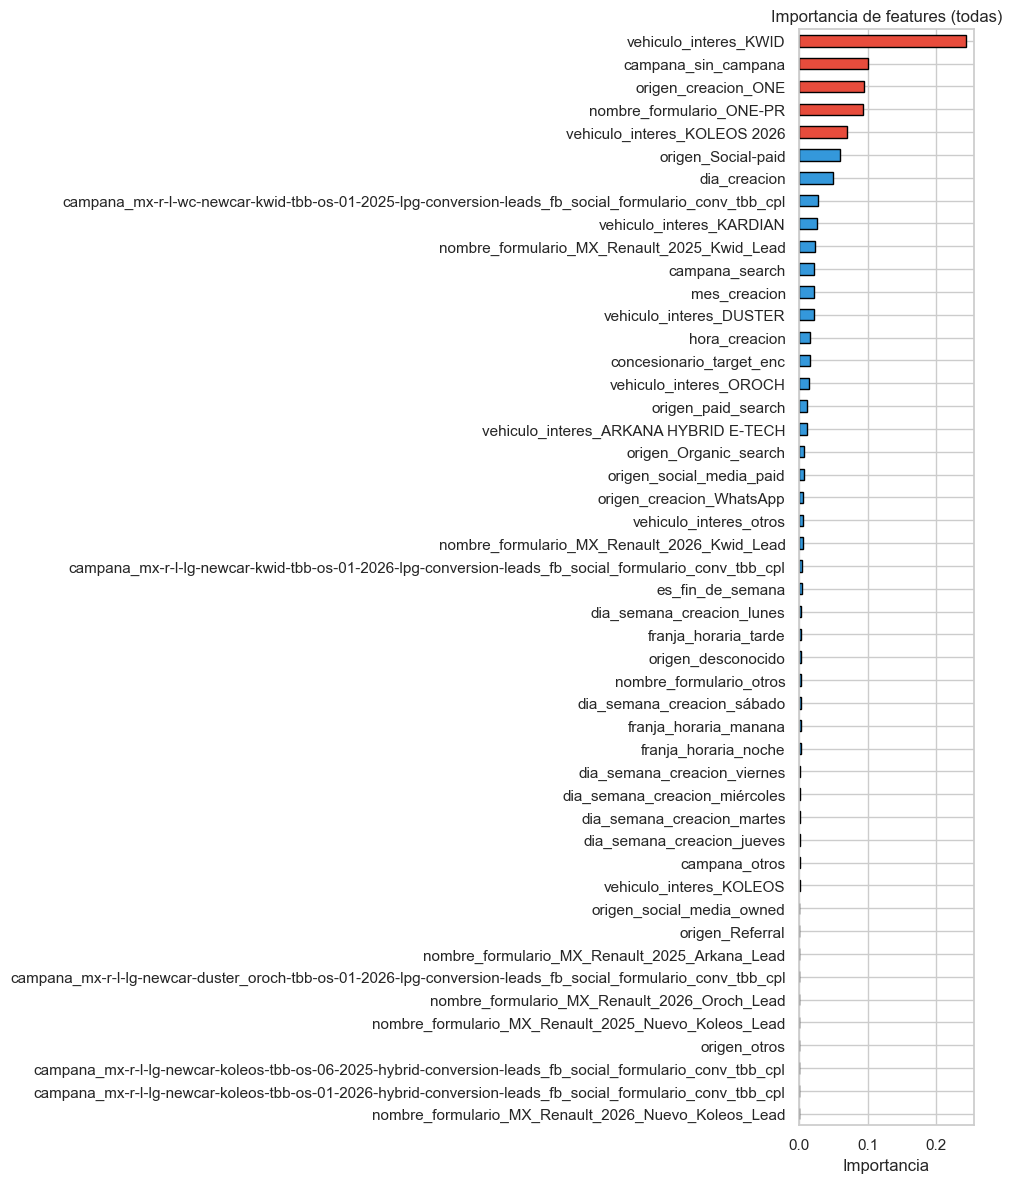


Top 10 features más importantes:
   1. vehiculo_interes_KWID                         0.2429 (24.3%)
   2. campana_sin_campana                           0.1002 (10.0%)
   3. origen_creacion_ONE                           0.0950 (9.5%)
   4. nombre_formulario_ONE-PR                      0.0941 (9.4%)
   5. vehiculo_interes_KOLEOS 2026                  0.0704 (7.0%)
   6. origen_Social-paid                            0.0597 (6.0%)
   7. dia_creacion                                  0.0499 (5.0%)
   8. campana_mx-r-l-wc-newcar-kwid-tbb-os-01-2025-lpg-conversion-leads_fb_social_formulario_conv_tbb_cpl 0.0283 (2.8%)
   9. vehiculo_interes_KARDIAN                      0.0262 (2.6%)
  10. nombre_formulario_MX_Renault_2025_Kwid_Lead   0.0239 (2.4%)


In [6]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#3498db" if v < feat_imp.quantile(0.9) else "#e74c3c" for v in feat_imp]
feat_imp.plot(kind="barh", color=colors, edgecolor="black", ax=ax)
ax.set_title("Importancia de features (todas)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

print("\nTop 10 features más importantes:")
for i, (feat, imp) in enumerate(feat_imp.tail(10).iloc[::-1].items(), 1):
    print(f"  {i:2d}. {feat:45s} {imp:.4f} ({imp/importances.sum()*100:.1f}%)")

**Conclusión importancia de features:** Tras eliminar `plataforma_MX_LEAD_QUALIF` (data leakage), la importancia se redistribuye de forma más realista:

1. **`vehiculo_interes_KWID` (~24%):** Es la feature más importante. Los leads interesados en el KWID tienen un comportamiento de conversión marcadamente diferente al resto.
2. **`origen_creacion_ONE` (~10-12%):** El origen del lead es un predictor fuerte de conversión.
3. **`campana_sin_campana` y `nombre_formulario_ONE-PR`:** Los leads sin campaña asociada y los que entran por formularios específicos también son predictivos.

Ahora el modelo depende de variables legítimas que sí estarían disponibles al momento de recibir un lead nuevo, lo que lo hace viable para producción.

## 7. Análisis de errores

Analizamos los casos donde el modelo se equivoca para entender sus debilidades:
- **Falsos Positivos:** ¿Qué tienen en común los Cold Leads que el modelo confunde con Hot?
- **Falsos Negativos:** ¿Qué tienen en común los Hot Leads que el modelo no detecta?

In [7]:
test_analysis = X_test.copy()
test_analysis["y_real"] = y_test.values
test_analysis["y_pred"] = y_pred
test_analysis["y_proba"] = y_proba

test_analysis["tipo_resultado"] = "TN"
test_analysis.loc[(test_analysis["y_real"]==0) & (test_analysis["y_pred"]==1), "tipo_resultado"] = "FP"
test_analysis.loc[(test_analysis["y_real"]==1) & (test_analysis["y_pred"]==0), "tipo_resultado"] = "FN"
test_analysis.loc[(test_analysis["y_real"]==1) & (test_analysis["y_pred"]==1), "tipo_resultado"] = "TP"

print("Distribución de resultados:")
print(test_analysis["tipo_resultado"].value_counts().to_string())

top_features = feat_imp.tail(5).index.tolist()

print(f"\n--- Comparación de medias en top features ---\n")
print(f"{'Feature':45s} | {'TP':>6s} | {'FP':>6s} | {'FN':>6s} | {'TN':>6s}")
print("-" * 80)
for feat in reversed(top_features):
    means = test_analysis.groupby("tipo_resultado")[feat].mean()
    print(f"  {feat:43s} | {means.get('TP',0):>6.3f} | {means.get('FP',0):>6.3f} | {means.get('FN',0):>6.3f} | {means.get('TN',0):>6.3f}")

Distribución de resultados:
tipo_resultado
TP    1069
TN     422
FP     106
FN      88

--- Comparación de medias en top features ---

Feature                                       |     TP |     FP |     FN |     TN
--------------------------------------------------------------------------------
  vehiculo_interes_KWID                       |  0.451 |  0.604 |  1.000 |  1.000
  campana_sin_campana                         |  0.279 |  0.849 |  0.898 |  0.872
  origen_creacion_ONE                         |  0.442 |  0.962 |  1.000 |  1.000
  nombre_formulario_ONE-PR                    |  0.435 |  0.868 |  1.000 |  0.995
  vehiculo_interes_KOLEOS 2026                |  0.200 |  0.000 |  0.000 |  0.000


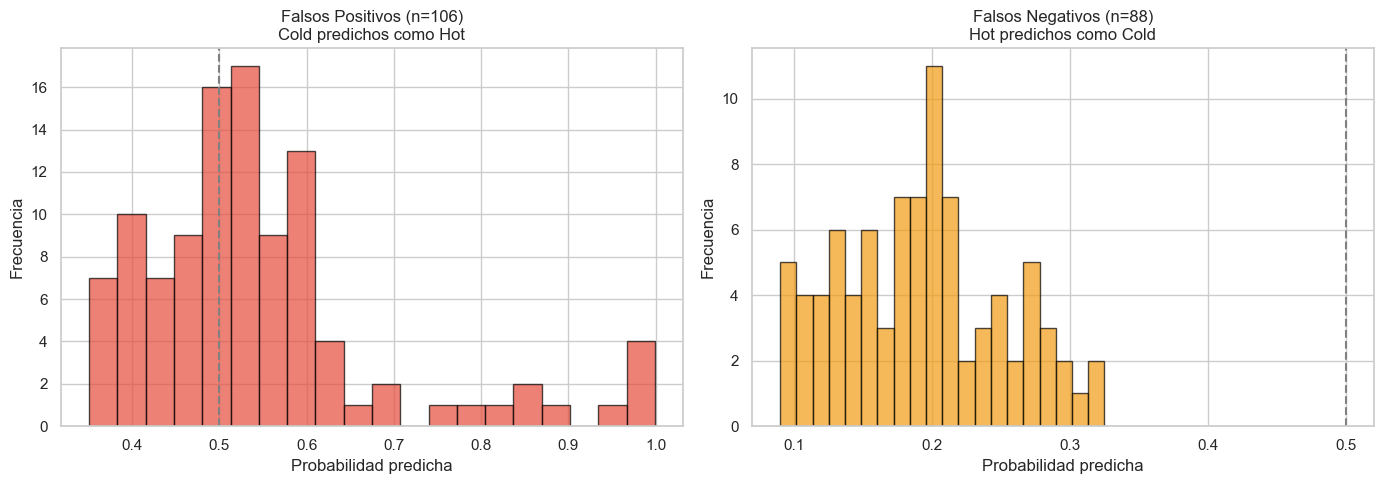

Falsos Positivos: probabilidad media = 0.547
Falsos Negativos: probabilidad media = 0.192


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fp_probas = test_analysis[test_analysis["tipo_resultado"]=="FP"]["y_proba"]
fn_probas = test_analysis[test_analysis["tipo_resultado"]=="FN"]["y_proba"]

axes[0].hist(fp_probas, bins=20, color="#e74c3c", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Falsos Positivos (n={len(fp_probas)})\nCold predichos como Hot")
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(x=0.5, color="gray", linestyle="--")

axes[1].hist(fn_probas, bins=20, color="#f39c12", edgecolor="black", alpha=0.7)
axes[1].set_title(f"Falsos Negativos (n={len(fn_probas)})\nHot predichos como Cold")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(x=0.5, color="gray", linestyle="--")

plt.tight_layout()
plt.show()

print(f"Falsos Positivos: probabilidad media = {fp_probas.mean():.3f}")
print(f"Falsos Negativos: probabilidad media = {fn_probas.mean():.3f}")

**Conclusi\u00f3n del an\u00e1lisis de errores (umbral = 0.35):** Los errores del modelo tienen un patr\u00f3n claro:
- **Falsos Positivos (106 casos, 6.3%):** Son Cold Leads con probabilidades entre 0.35-0.65 que el modelo env\u00eda como Hot. Son casos "borderline". Si se quisiera reducirlos, se podr\u00eda subir el umbral, pero a costa de perder m\u00e1s Hot Leads.
- **Falsos Negativos (88 casos, 5.2%):** Son Hot Leads que el modelo no detecta. Su perfil t\u00edpico: leads de KWID, sin campa\u00f1a, que entraron por el formulario gen\u00e9rico ONE-PR. Son el segmento m\u00e1s dif\u00edcil de predecir porque comparten caracter\u00edsticas con los Cold Leads.

## 8. Resumen de métricas finales

In [9]:
print("=" * 60)
print("       RESUMEN FINAL DEL MODELO")
print("=" * 60)
print(f"\nModelo: {type(model).__name__}")
print(f"Features: {X_test.shape[1]}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"\n--- M\u00e9tricas en Test (umbral = {UMBRAL}) ---")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\n--- Errores ---")
print(f"  Falsos Positivos: {fp} ({fp/len(y_test)*100:.1f}%) \u2192 Cold que el modelo dice Hot")
print(f"  Falsos Negativos: {fn} ({fn/len(y_test)*100:.1f}%) \u2192 Hot que el modelo pierde")
print(f"\n--- Feature m\u00e1s importante ---")
print(f"  {feat_imp.index[-1]}: {feat_imp.iloc[-1]:.4f}")

       RESUMEN FINAL DEL MODELO

Modelo: RandomForestClassifier
Features: 48
Train: 6,737 | Test: 1,685

--- Métricas en Test (umbral = 0.35) ---
  Accuracy:  0.8849
  Precision: 0.9098
  Recall:    0.9239
  F1-Score:  0.9168
  ROC-AUC:   0.9476

--- Errores ---
  Falsos Positivos: 106 (6.3%) → Cold que el modelo dice Hot
  Falsos Negativos: 88 (5.2%) → Hot que el modelo pierde

--- Feature más importante ---
  vehiculo_interes_KWID: 0.2429


## 9. Interpretabilidad con SHAP

Hasta ahora sabemos **qué features usa más el modelo** (sección 6), pero no sabemos **cómo** las usa ni **en qué dirección** afectan cada predicción. SHAP resuelve esto.

### ¿Qué es SHAP?

Piensa en el modelo como una **caja negra** que recibe los datos de un lead y dice *"85% de probabilidad de ser Hot"*. SHAP **abre la caja** y te da una factura detallada:

> Empezamos en el promedio general (68.7%). Luego:
> - Preguntó por KWID → **bajó 15%** (KWID tiene menor conversión que otros modelos)
> - Entró por campaña de Facebook → **subió 25%**
> - Es fin de semana → **subió 5%**
> - Resultado final: **83%** de ser Hot

Cada feature **suma o resta** puntos a la probabilidad. SHAP calcula exactamente cuánto aporta cada una.

### Tipos de gráficos SHAP:
- **Bar plot (9.1):** Ranking de features por cuánto mueven la predicción en promedio. Es más preciso que la importancia de Gini de la sección 6.
- **Beeswarm / abejas (9.2):** Cada punto es un lead. Muestra la **dirección** del efecto: si tener un valor alto en una feature empuja hacia Hot o hacia Cold.
- **Waterfall / cascada (9.3, 9.4):** Para un lead específico, muestra paso a paso cómo el modelo llegó a su predicción, desde la probabilidad base hasta la final.

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print(f"SHAP values calculados para {X_test.shape[0]:,} leads x {X_test.shape[1]} features")

SHAP values calculados para 1,685 leads x 48 features


### 9.1 Importancia global (Bar plot)

Ranking de features por su impacto promedio en las predicciones. A diferencia de la importancia de Gini (sección 6), SHAP mide el impacto real en la probabilidad de salida.

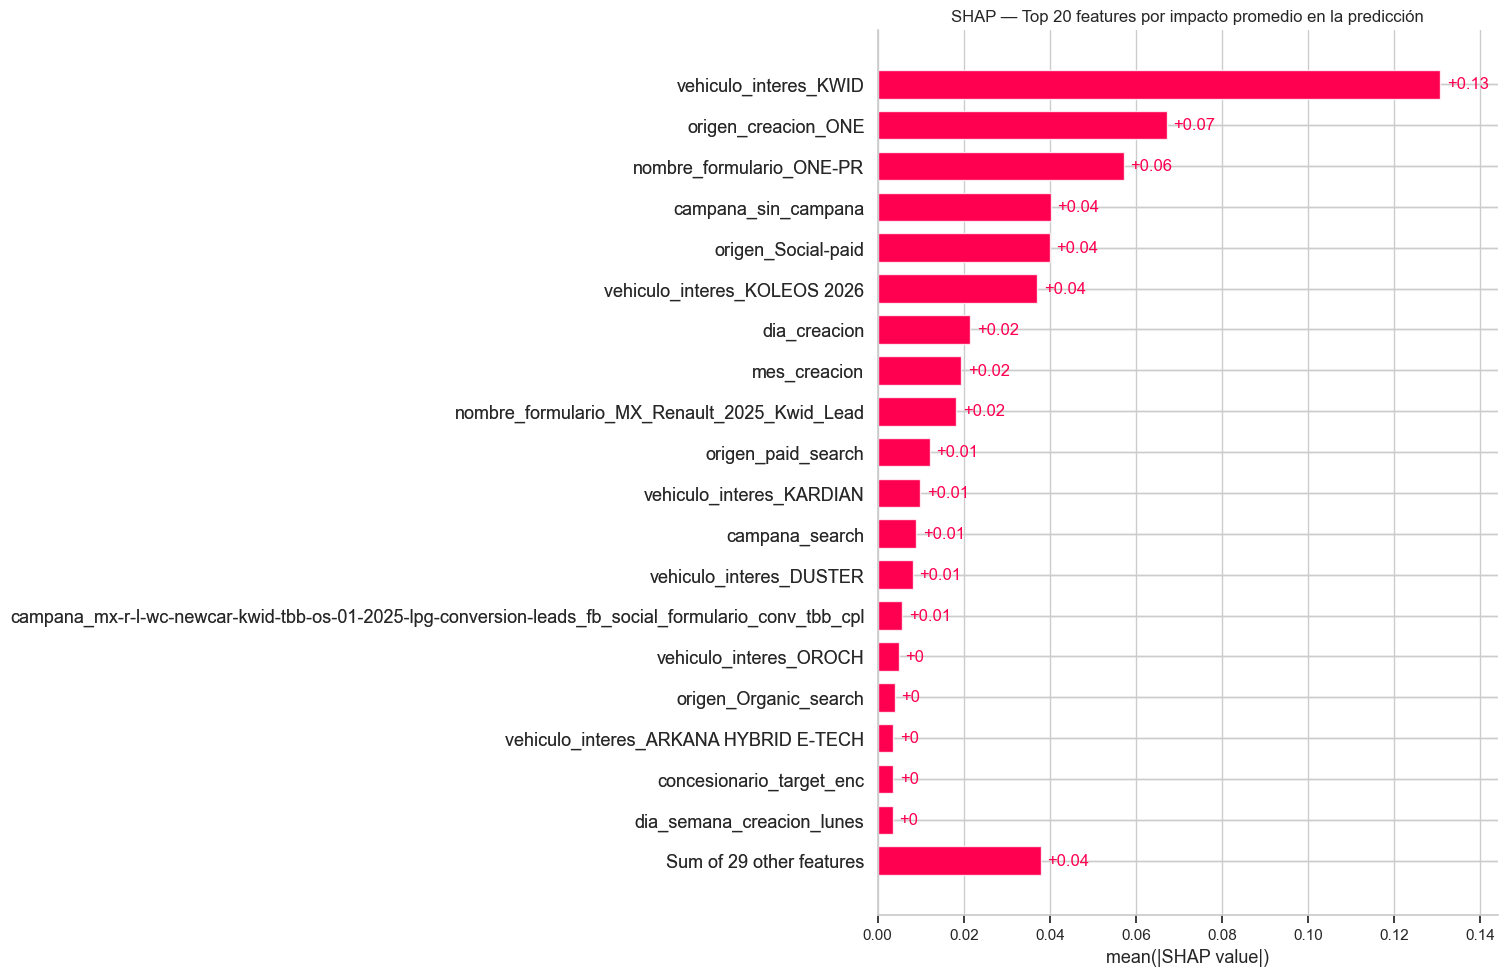

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.bar(shap_values[:, :, 1], max_display=20, show=False)
plt.title("SHAP — Top 20 features por impacto promedio en la predicción")
plt.tight_layout()
plt.show()

### 9.2 Summary plot (gráfico de abejas)

Este gráfico responde una pregunta simple: **¿qué hace que un lead sea Hot o Cold?**

Cada puntito es un lead real del test set (1,685 leads). Funciona así:

- Si un punto está a la **derecha** → esa característica hizo que el modelo pensara **«les Hot!»**
- Si un punto está a la **izquierda** → esa característica hizo que el modelo pensara **«les Cold»**
- El **color** indica si el lead tiene (rojo) o no tiene (azul) esa característica

**Cómo leerlo con un ejemplo concreto:**

Mira la fila de `vehiculo_interes_KWID`:
- Los puntos **rojos** (= leads que SÍ preguntaron por KWID) están a la **izquierda** → preguntar por KWID empuja hacia Cold. Tiene sentido: KWID es el auto más barato y atrae muchos curiosos que no compran.
- Los puntos **azules** (= leads que NO preguntaron por KWID, o sea preguntaron por otro modelo) están a la **derecha** → preguntar por otro vehículo empuja hacia Hot.

Otro ejemplo: mira `campana_sin_campana`:
- Puntos **rojos** (= leads SIN campaña) a la **izquierda** → no tener campaña empuja hacia Cold.
- Puntos **azules** (= leads que SÍ llegaron por una campaña) a la **derecha** → tener campaña empuja hacia Hot.

**En resumen:** las features que aparecen más arriba son las que más influyen. Si los colores están bien separados (rojos a un lado, azules al otro), la feature tiene un efecto claro. Si están mezclados, el efecto es más ambiguo.

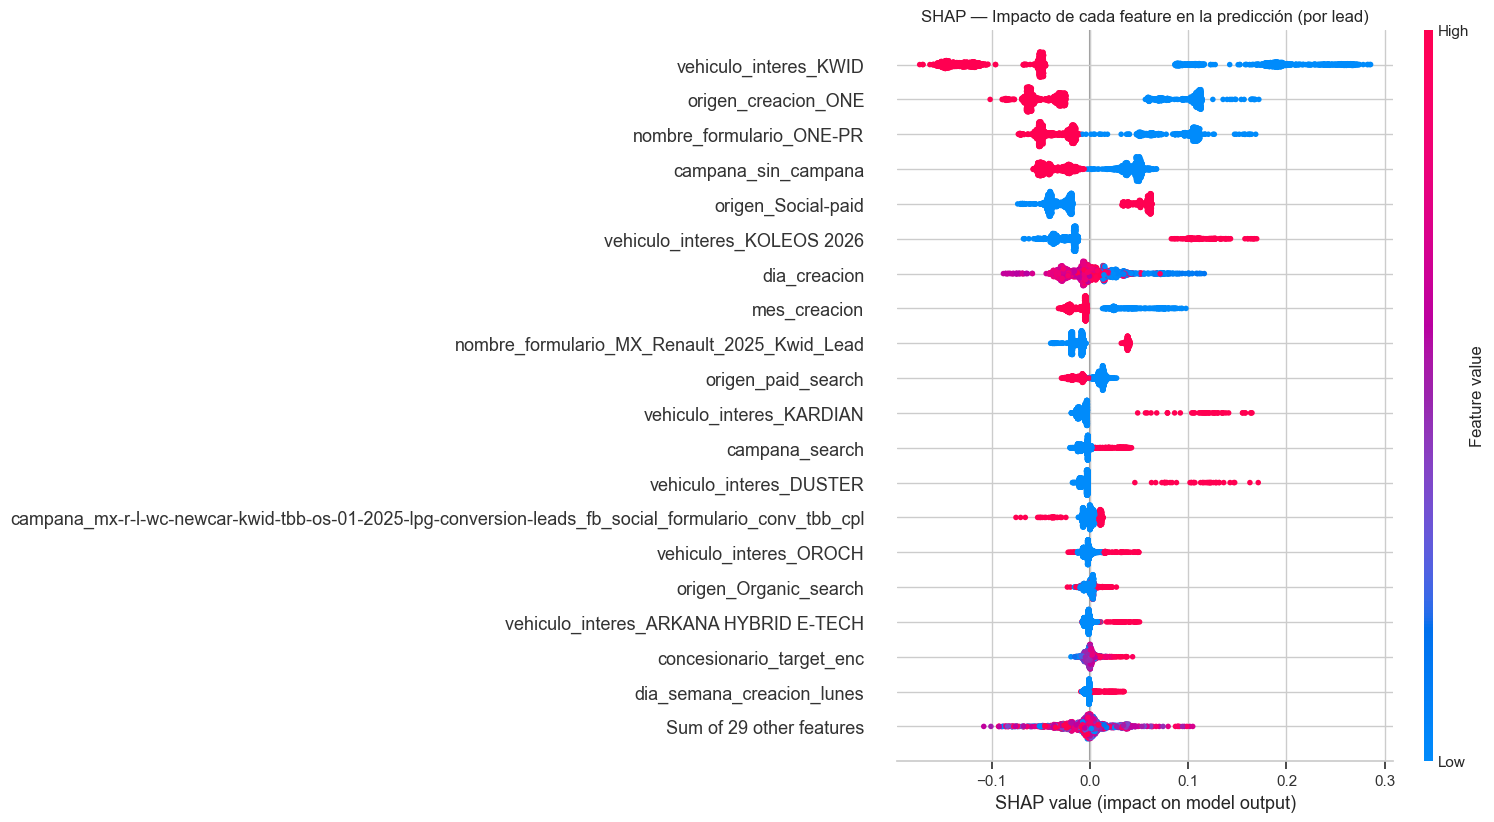

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.beeswarm(shap_values[:, :, 1], max_display=20, show=False)
plt.title("SHAP — Impacto de cada feature en la predicción (por lead)")
plt.tight_layout()
plt.show()

### 9.3 Ejemplo individual — ¿Por qué este lead es Hot?

Tomamos un lead clasificado como Hot con alta confianza y mostramos paso a paso cómo el modelo llegó a esa decisión. El gráfico de cascada muestra la contribución de cada feature, empezando desde la probabilidad base y sumando/restando hasta llegar a la predicción final.

Lead #1: probabilidad = 99.8%, predicción = Hot, real = Hot



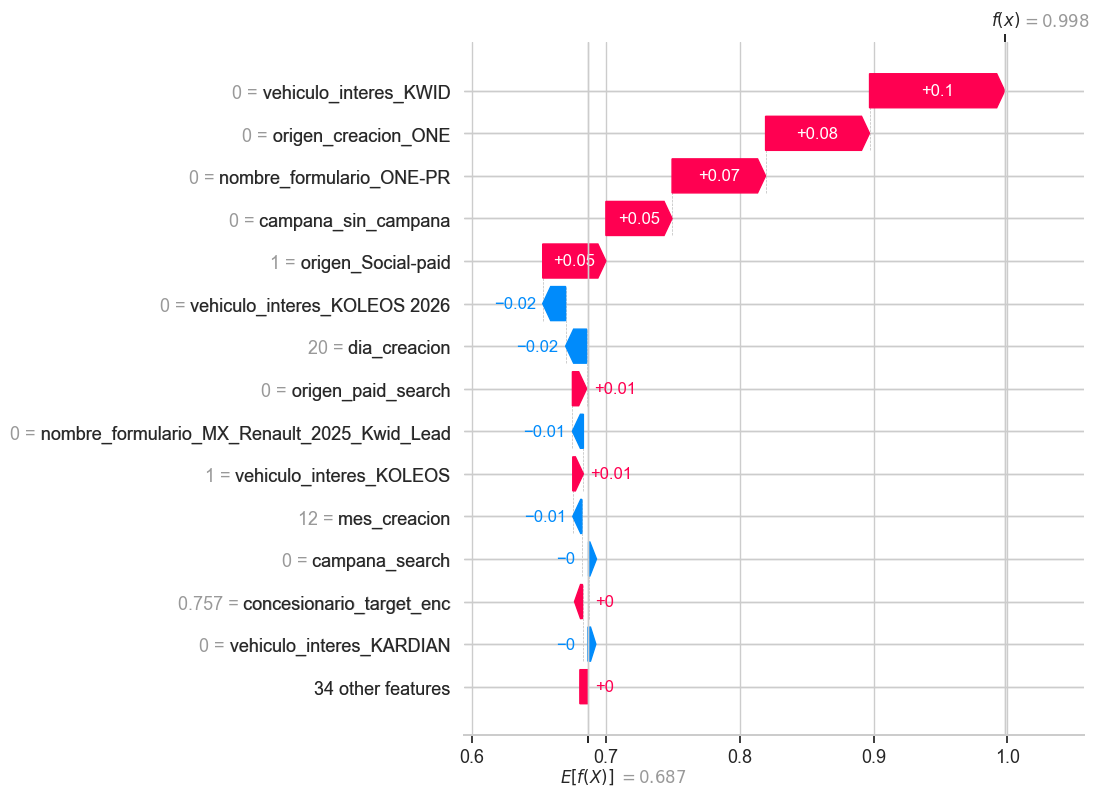

In [13]:
hot_indices = np.where((y_pred == 1) & (y_proba > 0.8))[0]
example_idx = hot_indices[0]

print(f"Lead #{example_idx}: probabilidad = {y_proba[example_idx]:.1%}, predicción = Hot, real = {'Hot' if y_test.iloc[example_idx]==1 else 'Cold'}\n")

shap.plots.waterfall(shap_values[example_idx, :, 1], max_display=15, show=True)

### 9.4 Ejemplo individual — ¿Por qué este lead es Cold?

Ahora hacemos lo mismo con un lead clasificado como Cold para ver qué factores empujan hacia la no-conversión.

Lead #9: probabilidad = 16.6%, predicción = Cold, real = Cold



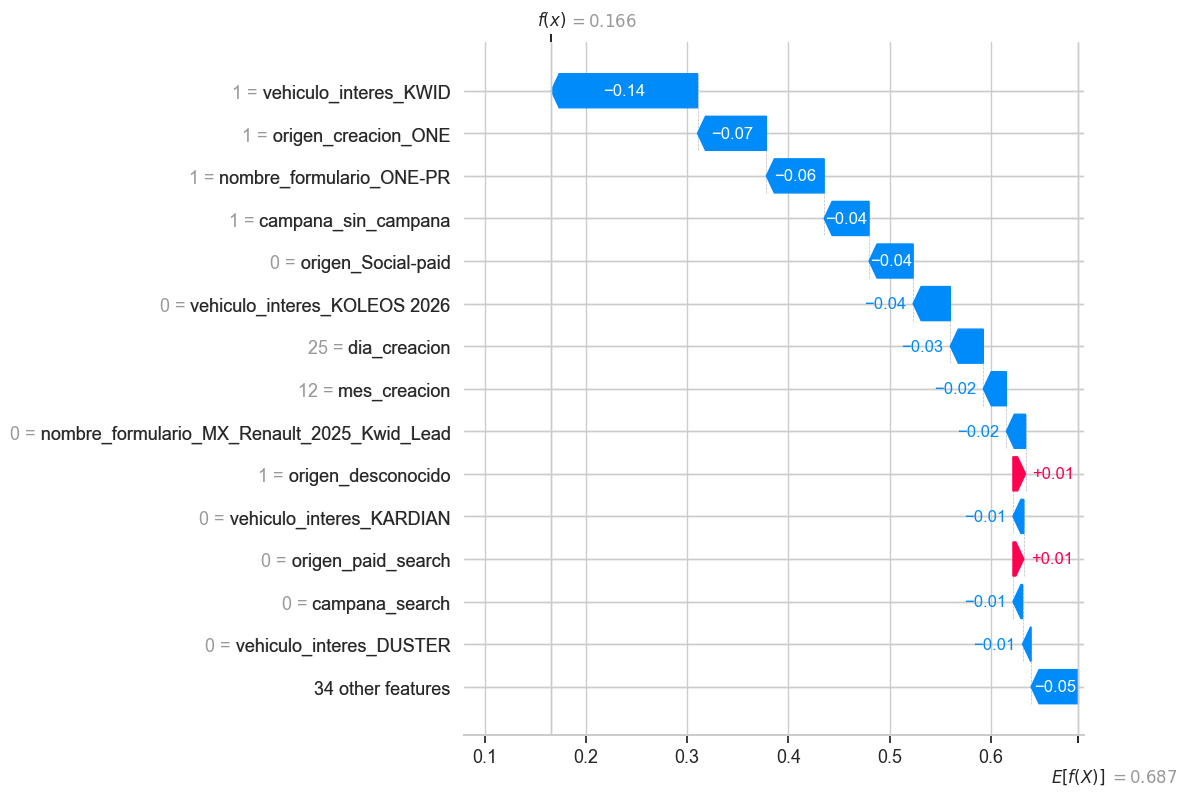

In [14]:
cold_indices = np.where((y_pred == 0) & (y_proba < 0.2))[0]
example_cold_idx = cold_indices[0]

print(f"Lead #{example_cold_idx}: probabilidad = {y_proba[example_cold_idx]:.1%}, predicción = Cold, real = {'Hot' if y_test.iloc[example_cold_idx]==1 else 'Cold'}\n")

shap.plots.waterfall(shap_values[example_cold_idx, :, 1], max_display=15, show=True)

**Conclusión SHAP:** La interpretabilidad confirma que el modelo (sin la feature con data leakage) toma decisiones basadas en variables legítimas. Las features más influyentes son el vehículo de interés, el origen del lead y la campaña asociada. Los ejemplos individuales muestran que cada predicción se puede explicar con 3-5 factores dominantes, lo que facilita la comunicación con el equipo de ventas: *"Este lead es Hot porque preguntó por KWID, entró por formulario ONE-PR y no tiene campaña asociada."*

## 10. Conclusiones y recomendaciones

### Fortalezas del modelo
- **ROC-AUC ~0.95**: Excelente capacidad de discriminaci\u00f3n entre Hot y Cold Leads, incluso sin la feature con data leakage.
- **Precision ~91%** (umbral 0.35): Cuando el modelo dice que un lead es Hot, acierta 9 de cada 10 veces.
- **Recall ~92%** (umbral 0.35): Captura m\u00e1s de 9 de cada 10 Hot Leads reales. Se mejor\u00f3 respecto al umbral default (0.5) que ten\u00eda 90.8%.
- **Sin data leakage**: Se elimin\u00f3 `plataforma_MX_LEAD_QUALIF` (indicaba si el lead ya fue clasificado). Las m\u00e9tricas actuales reflejan el rendimiento real en producci\u00f3n.
- **Interpretable con SHAP**: Cada predicci\u00f3n individual se puede explicar, generando confianza en el equipo de ventas.

### Umbral optimizado
Se seleccion\u00f3 un umbral de **0.35** (en lugar del default 0.5) para priorizar la captura de Hot Leads:
- Se rescataron **18 Hot Leads** que con el umbral default se perd\u00edan.
- A cambio, se env\u00edan **44 Cold Leads** adicionales al concesionario (costo aceptable).

### Limitaciones
- **Falsos Positivos (6.3%)**: M\u00e1s Cold Leads llegan al concesionario que con umbral 0.5, pero el vendedor los descarta r\u00e1pidamente.
- **Falsos Negativos (5.2%)**: A\u00fan se pierden 88 Hot Leads. Son leads de KWID, sin campa\u00f1a, por formulario gen\u00e9rico \u2014 el perfil m\u00e1s dif\u00edcil de predecir.
- **Ventana temporal limitada**: Los datos cubren solo dic 2025 - ene 2026. El modelo podr\u00eda no generalizar a otros per\u00edodos.

### Recomendaciones para producci\u00f3n
1. **Monitorear drift**: Verificar mensualmente que la distribuci\u00f3n de features y la tasa de conversi\u00f3n no cambien.
2. **Reentrenar**: Con datos nuevos cada 3-6 meses para capturar cambios en el comportamiento.
3. **Umbral ajustable**: El umbral 0.35 es una recomendaci\u00f3n inicial. Si el concesionario reporta demasiados Cold Leads, subir a 0.40-0.45.
4. **Incorporar m\u00e1s datos**: Ampliar la ventana temporal para capturar estacionalidad completa.
5. **Usar SHAP en producci\u00f3n**: Generar explicaciones para cada lead nuevo.
6. **Validar con el equipo de ventas**: Confirmar que las features importantes tienen sentido de negocio.